In [1]:
import cdsapi
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr


In [2]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [3]:
# Get the bounds of the sierras polygon
minx, miny, maxx, maxy = sierras.total_bounds

In [6]:
c = cdsapi.Client()

# Example for Daily ERA5-Land Data
c.retrieve(
    'reanalysis-era5-land',
    {
        'variable': [
            '2m_temperature', 'total_precipitation', 'snowfall',
        ],
        'year': [
            '1984','1985', '1986', '1987', '1988', '1989', '1990',
            '1991', '1992', '1993', '1994', '1995', '1996',
            '1997', '1998', '1999', '2000', '2001', '2002',
            '2003', '2004', '2005', '2006', '2007', '2008',
            '2009', '2010', '2011', '2012', '2013', '2014',
            '2015', '2016', '2017', '2018', '2019', '2020',
            '2021',
        ],
        'month': [
            '01', '02', '03', '04','10', '11', '12'
        ],
        'day': [
            '01', '02', '03', '04', '05', '06', '07', '08', '09', '10',
            '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
            '21', '22', '23', '24', '25', '26', '27', '28', '29', '30',
            '31'
        ],
        'time': '00:00', # Daily accumulation or snapshot
        'area': [maxy, minx, miny, maxx], # North, West, South, East
        'format': 'netcdf',
    },
    'sierra_nevada_era5_land.nc')

HTTPError: 403 Client Error: Forbidden for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/reanalysis-era5-land/execution
cost limits exceeded
Your request is too large, please reduce your selection.

In [8]:
c = cdsapi.Client()

# Example for Daily ERA5-Land Data
c.retrieve(
    'reanalysis-era5-land',
    {
        'variable': [
            '2m_temperature', 'total_precipitation', 'snowfall',
        ],
        'year': [
            '1985', '1986', '1987', '1988', '1989', '1990',
        ],
        'month': [
            '01', '02', '03', '04','10', '11', '12'
        ],
        'day': [
            '01', '02', '03', '04', '05', '06', '07', '08', '09', '10',
            '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
            '21', '22', '23', '24', '25', '26', '27', '28', '29', '30',
            '31'
        ],
        'time': '00:00', # Daily accumulation or snapshot
        'area': [maxy, minx, miny, maxx], # North, West, South, East
        'format': 'netcdf',
    },
    'sierra_nevada_era5_land.nc')

2026-02-06 16:49:51,409 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-02-06 16:49:51,410 INFO Request ID is 466478c1-75c0-4f66-8c96-ac1db7e2c91a
2026-02-06 16:49:51,597 INFO status has been updated to accepted
2026-02-06 16:50:00,503 INFO status has been updated to running
2026-02-06 17:00:14,409 INFO status has been updated to successful


14b07c2905fc1a012e7e1ee70bef3459.zip:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

'sierra_nevada_era5_land.nc'

In [26]:
import cdsapi

dataset = "derived-era5-single-levels-daily-statistics"
request = {
    "product_type": "reanalysis",
    "variable": ["2m_temperature"],
    "year": "1985",
    "month": [
        "01", "02", "03",
        "04", "10", "11",
        "12"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "daily_statistic": "daily_mean",
    "time_zone": "utc+00:00",
    "frequency": "6_hourly",
    "area": [maxy, minx, miny, maxx]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()

2026-02-06 19:20:37,158 INFO Request ID is d9d00748-ba88-4402-aa1e-b5b9ab1141bf
2026-02-06 19:20:37,401 INFO status has been updated to accepted
2026-02-06 19:22:33,268 INFO status has been updated to running
2026-02-06 19:24:59,295 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-06 19:24:59,299 INFO status has been updated to successful


63a6ec5576fce3c2d7ebab29501e8e38.nc:   0%|          | 0.00/209k [00:00<?, ?B/s]

'63a6ec5576fce3c2d7ebab29501e8e38.nc'

In [28]:
temp_1985 = xr.open_dataset('63a6ec5576fce3c2d7ebab29501e8e38.nc')

In [29]:
temp_1985

<xarray.Dataset> Size: 334kB
Dimensions:     (latitude: 23, longitude: 17, valid_time: 212)
Coordinates:
  * latitude    (latitude) float64 184B 40.32 40.07 39.82 ... 35.32 35.07 34.82
  * longitude   (longitude) float64 136B -121.9 -121.7 -121.4 ... -118.2 -117.9
  * valid_time  (valid_time) datetime64[ns] 2kB 1985-01-01 ... 1985-12-31
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 332kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-07T03:23 GRIB to CDM+CF via cfgrib-0.9.1...

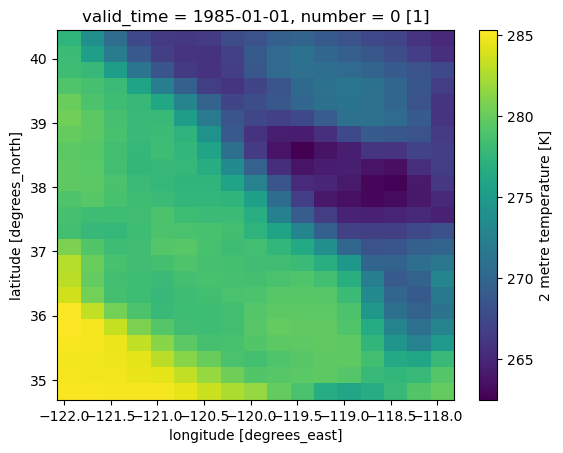

In [30]:
temp_1985.t2m.sel(valid_time='1985-01-01').plot()

In [25]:
c = cdsapi.Client()

# Example for Daily ERA5-Land Data
c.retrieve(
    'derived-era5-single-levels-daily-statistics',
    {
        'variable': [
            '2m_temperature', 'total_precipitation', 'snowfall',
        ],
        'year': [
            '1985', '1986', '1987', '1988', '1989', '1990',
        ],
        'month': [
            '01', '02', '03', '04','10', '11', '12'
        ],
        'day': [
            '01', '02', '03', '04', '05', '06', '07', '08', '09', '10',
            '11', '12', '13', '14', '15', '16', '17', '18', '19', '20',
            '21', '22', '23', '24', '25', '26', '27', '28', '29', '30',
            '31'
        ],
        'time': '00:00', # Daily accumulation or snapshot
        'area': [maxy, minx, miny, maxx], # North, West, South, East
        'format': 'netcdf',
    },
    '../data/misc/sierra_nevada_era5_1985_1990.nc')

HTTPError: 404 Client Error: Not Found for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/reanalysis-era5
process not found
dataset reanalysis-era5 not found

In [ ]:
# took 10m 27s to download daily 3 variables for 1985 - 1990 for oct-april

In [9]:
era5_land = xr.open_dataset('sierra_nevada_era5_land.nc')

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'ee', 'rasterio', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [10]:
pwd

'/Users/hannah/Documents/Grad_Documents/Research/analog_snowmapping/notebooks'

In [11]:
import zipfile

# Unzip the ERA5 data
with zipfile.ZipFile('sierra_nevada_era5_land.nc', 'r') as zip_ref:
    zip_ref.extractall('era5_data/')

# Then open the extracted file
era5_land = xr.open_dataset('era5_data/data_0.nc')

In [12]:
era5_land

<xarray.Dataset> Size: 36MB
Dimensions:     (valid_time: 1273, latitude: 57, longitude: 41)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 10kB 1985-01-01 ... 1990-12-31
  * latitude    (latitude) float64 456B 40.42 40.32 40.22 ... 35.02 34.92 34.82
  * longitude   (longitude) float64 328B -121.9 -121.8 -121.7 ... -118.0 -117.9
    expver      (valid_time) <U4 20kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 12MB ...
    tp          (valid_time, latitude, longitude) float32 12MB ...
    sf          (valid_time, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-07T00:59 GRIB to CDM+CF via cfgrib-0.9.1...

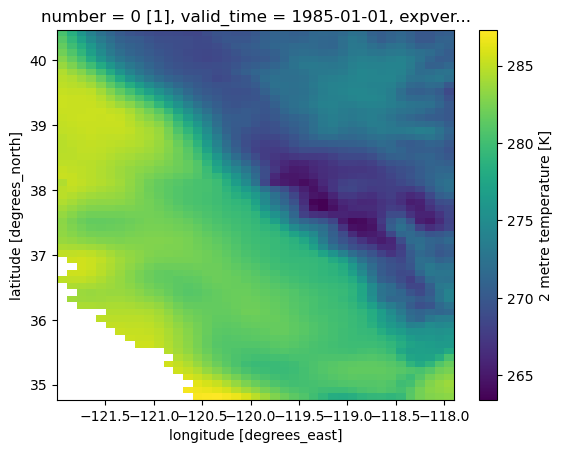

In [14]:
era5_land.t2m.sel(valid_time='1985-01-01').plot()

In [22]:
era5_land = era5_land.rio.write_crs('epsg:4326')

In [23]:
era5_land_sierras = era5_land.rio.clip(sierras.geometry)

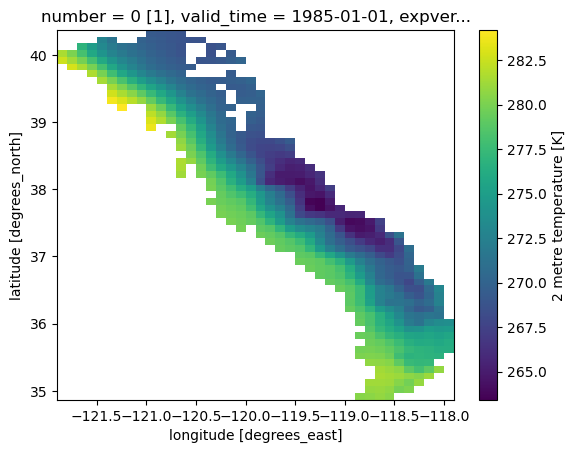

In [24]:
era5_land_sierras.t2m.sel(valid_time='1985-01-01').plot()

### Download ERA5 Daily Statistics (1984-2021)

In [33]:
import os

# Create output folder
output_dir = '../data/era5_daily'
os.makedirs(output_dir, exist_ok=True)

c = cdsapi.Client()

# Define the bounding box (North, West, South, East)
area = [maxy, minx, miny, maxx]

# Single years (CDS cost limits prevent batching)
year_batches = [[y] for y in range(1984, 2022)]

# Standard months for non-1984 years
standard_months = ['01', '02', '03', '04', '10', '11', '12']

# Download temperature (daily_mean) for each batch
print("="*60)
print("Downloading 2m Temperature (daily_mean)")
print("="*60)

for batch in year_batches:
    batch_name = f"{batch[0]}_{batch[-1]}" if len(batch) > 1 else str(batch[0])
    output_file = f'{output_dir}/era5_t2m_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    # Use special months for 1984 batch
    months = ['10', '11', '12'] if batch == [1984] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading {len(batch)} years, months {months}...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': '2m_temperature',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_mean',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nTemperature downloads complete!")

  1984: Already exists, skipping
  1985: Downloading 1 years, months ['01', '02', '03', '04', '10', '11', '12']...


2026-02-06 19:49:57,006 INFO Request ID is 46e1012c-d3a3-41a5-9396-2217ef0091bb
2026-02-06 19:49:57,226 INFO status has been updated to accepted
2026-02-06 19:50:11,648 INFO status has been updated to running
2026-02-06 19:50:19,462 INFO status has been updated to successful


63a6ec5576fce3c2d7ebab29501e8e38.nc:   0%|          | 0.00/209k [00:00<?, ?B/s]

  1985: Done -> ../data/era5_daily/era5_t2m_1985.nc
  1986: Downloading 1 years, months ['01', '02', '03', '04', '10', '11', '12']...


2026-02-06 19:50:23,348 INFO Request ID is 2b884954-49b7-48cb-865a-f86a1f0e54bd
2026-02-06 19:50:23,577 INFO status has been updated to accepted
2026-02-06 19:50:46,465 INFO status has been updated to running
2026-02-06 19:52:20,172 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-06 19:52:20,173 INFO status has been updated to successful


...

85c5a3668e4c4800f960af2258c81e0e.nc:   0%|          | 0.00/208k [00:00<?, ?B/s]

  2020: Done -> ../data/era5_daily/era5_t2m_2020.nc
  2021: Downloading 1 years, months ['01', '02', '03', '04', '10', '11', '12']...


2026-02-06 21:09:49,860 INFO Request ID is fdbb198f-7e2b-48a6-880a-c392cf8c86ae
2026-02-06 21:09:50,110 INFO status has been updated to accepted
2026-02-06 21:11:07,145 INFO status has been updated to running
2026-02-06 21:12:44,248 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-06 21:12:44,252 INFO status has been updated to successful


6f196935de3081ddb97f6c97cfff33f3.nc:   0%|          | 0.00/208k [00:00<?, ?B/s]

  2021: Done -> ../data/era5_daily/era5_t2m_2021.nc

Temperature downloads complete!


In [36]:
# Download precipitation (daily_sum) for each year - SEPARATE from snowfall due to cost limits
print("="*60)
print("Downloading Total Precipitation (daily_sum)")
print("="*60)

for batch in year_batches:
    batch_name = f"{batch[0]}_{batch[-1]}" if len(batch) > 1 else str(batch[0])
    output_file = f'{output_dir}/era5_tp_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    months = ['10', '11', '12'] if batch == [1984] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': 'total_precipitation',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_sum',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nPrecipitation downloads complete!")

  1984: Already exists, skipping
  1985: Already exists, skipping
  1986: Downloading...


2026-02-07 10:29:46,747 INFO Request ID is 8e067056-41b1-4fc6-a42d-ac5b9a2e5758
2026-02-07 10:29:46,981 INFO status has been updated to accepted
2026-02-07 10:31:04,265 INFO status has been updated to successful


db7fa86c1a6fe43ff83c1edfef38eecd.nc:   0%|          | 0.00/138k [00:00<?, ?B/s]

  1986: Done -> ../data/era5_daily/era5_tp_1986.nc
  1987: Downloading...


2026-02-07 10:31:07,420 INFO Request ID is ba8ff4a7-8f82-44a7-8422-7ebec36b6f13
2026-02-07 10:31:07,737 INFO status has been updated to accepted
2026-02-07 10:31:22,314 INFO status has been updated to running
2026-02-07 10:33:03,746 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-07 10:33:03,748 INFO status has been updated to successful


...

5787e377322f27743283fc21a13fc4cc.nc:   0%|          | 0.00/120k [00:00<?, ?B/s]

  2020: Done -> ../data/era5_daily/era5_tp_2020.nc
  2021: Downloading...


2026-02-07 11:50:47,812 INFO Request ID is 985a3eb1-f92e-47e3-9526-1ed5def88e3c
2026-02-07 11:50:48,119 INFO status has been updated to accepted
2026-02-07 11:51:10,452 INFO status has been updated to running
2026-02-07 11:52:44,028 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-07 11:52:44,030 INFO status has been updated to successful


f2902cf774890f196b61a67bd28cbb8b.nc:   0%|          | 0.00/130k [00:00<?, ?B/s]

  2021: Done -> ../data/era5_daily/era5_tp_2021.nc

Precipitation downloads complete!


In [37]:
# Download snowfall (daily_sum) for each year - SEPARATE due to cost limits
print("="*60)
print("Downloading Snowfall (daily_sum)")
print("="*60)

for batch in year_batches:
    batch_name = f"{batch[0]}_{batch[-1]}" if len(batch) > 1 else str(batch[0])
    output_file = f'{output_dir}/era5_sf_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    months = ['10', '11', '12'] if batch == [1984] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': 'snowfall',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_sum',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nSnowfall downloads complete!")

  1984: Downloading...


2026-02-07 11:52:47,960 INFO Request ID is 1b189d61-ad5c-4f3b-8876-3a5ee343baac
2026-02-07 11:52:48,193 INFO status has been updated to accepted
2026-02-07 11:53:02,673 INFO status has been updated to running
2026-02-07 11:54:05,283 INFO status has been updated to successful


f5f99ca523d2f54d04ec80cbf642557e.nc:   0%|          | 0.00/65.9k [00:00<?, ?B/s]

  1984: Done -> ../data/era5_daily/era5_sf_1984.nc
  1985: Downloading...


2026-02-07 11:54:08,427 INFO Request ID is 472d0de2-2511-445c-b0f1-5c97b53b78ea
2026-02-07 11:54:08,652 INFO status has been updated to accepted
2026-02-07 11:54:23,264 INFO status has been updated to running
2026-02-07 11:56:04,901 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-07 11:57:03,317 INFO status has been updated to successful


...

1afb246afa968a6e1edba937255848af.nc:   0%|          | 0.00/78.8k [00:00<?, ?B/s]

  2020: Done -> ../data/era5_daily/era5_sf_2020.nc
  2021: Downloading...


2026-02-07 13:30:41,334 INFO Request ID is ec855d9c-b232-4d8a-9def-957c51f937c7
2026-02-07 13:30:41,567 INFO status has been updated to accepted
2026-02-07 13:30:55,976 INFO status has been updated to running
2026-02-07 13:32:37,558 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-07 13:32:37,561 INFO status has been updated to successful


5cd2cbdb6e0fa7d3b363fa0f1a2edc23.nc:   0%|          | 0.00/83.5k [00:00<?, ?B/s]

  2021: Done -> ../data/era5_daily/era5_sf_2021.nc

Snowfall downloads complete!


### Download ERA5 700mb Temperature (Pressure Levels)

700mb (~3000m elevation) temperature represents the free atmosphere, unaffected by ERA5's terrain smoothing. This is a more direct predictor of freezing level and snow line elevation than surface temperature.

**Scientific basis:**
- Lundquist et al. (2008, J. Hydromet) showed 700mb temp correlates with observed snow levels
- Knowles et al. (2006, J. Climate) used freezing level to analyze rain vs snow trends
- AR research (Rutz et al. 2014, Mon. Wea. Rev.) uses 700mb for storm characterization

**Note:** This uses `reanalysis-era5-pressure-levels` (different from the single-levels daily statistics product above)

In [41]:
# Download 700mb temperature from ERA5 pressure levels
print("="*60)
print("Downloading 700mb Temperature (pressure levels)")
print("="*60)

c = cdsapi.Client()

for batch in year_batches:
    batch_name = f"{batch[0]}_{batch[-1]}" if len(batch) > 1 else str(batch[0])
    output_file = f'{output_dir}/era5_t700_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    # Use special months for 1984 batch (only Oct-Dec available for WY1985)
    months = ['10', '11', '12'] if batch == [1984] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading...")
    
    c.retrieve(
        'reanalysis-era5-pressure-levels',
        {
            'product_type': 'reanalysis',
            'variable': 'temperature',
            'pressure_level': '700',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': '12:00',  # Daily snapshot at noon UTC
            'area': area,
            'format': 'netcdf',
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\n700mb temperature downloads complete!")

  1984: Downloading...


2026-02-08 10:48:22,190 INFO Request ID is 36d9e130-9267-413a-a374-97044172ac80
2026-02-08 10:48:22,429 INFO status has been updated to accepted
2026-02-08 10:48:37,208 INFO status has been updated to running
2026-02-08 10:49:14,142 INFO status has been updated to successful


fe0930fdcdb58b22c330898b497a1ba.nc:   0%|          | 0.00/101k [00:00<?, ?B/s]

  1984: Done -> ../data/era5_daily/era5_t700_1984.nc
  1985: Downloading...


2026-02-08 10:49:16,922 INFO Request ID is 85bd3338-83c7-48c9-b3d6-44ff96beb5ce
2026-02-08 10:49:17,212 INFO status has been updated to accepted
2026-02-08 10:49:39,492 INFO status has been updated to running
2026-02-08 10:50:08,619 INFO status has been updated to accepted
2026-02-08 10:50:34,484 INFO status has been updated to running
2026-02-08 10:52:11,602 INFO status has been updated to successful


...

d0b2d546915e75a2c22465aad0cb95f7.nc:   0%|          | 0.00/204k [00:00<?, ?B/s]

  2020: Done -> ../data/era5_daily/era5_t700_2020.nc
  2021: Downloading...


2026-02-08 11:35:52,364 INFO Request ID is 088b15e4-76af-4eb6-8cc2-f26b9c451d41
2026-02-08 11:35:52,648 INFO status has been updated to accepted
2026-02-08 11:36:07,088 INFO status has been updated to running
2026-02-08 11:36:43,904 INFO status has been updated to successful


98e50f21806e085db98580d99bdd7772.nc:   0%|          | 0.00/202k [00:00<?, ?B/s]

  2021: Done -> ../data/era5_daily/era5_t700_2021.nc

700mb temperature downloads complete!


In [44]:
# Combine all batched files into one dataset
print("="*60)
print("Combining all ERA5 data into one file")
print("="*60)

# Find all files by variable type
t2m_files = sorted([f for f in os.listdir(output_dir) if f.startswith('era5_t2m_') and f.endswith('.nc')])
tp_files = sorted([f for f in os.listdir(output_dir) if f.startswith('era5_tp_') and f.endswith('.nc')])
sf_files = sorted([f for f in os.listdir(output_dir) if f.startswith('era5_sf_') and f.endswith('.nc')])
t700_files = sorted([f for f in os.listdir(output_dir) if f.startswith('era5_t700_') and f.endswith('.nc')])

t2m_paths = [f'{output_dir}/{f}' for f in t2m_files]
tp_paths = [f'{output_dir}/{f}' for f in tp_files]
sf_paths = [f'{output_dir}/{f}' for f in sf_files]
t700_paths = [f'{output_dir}/{f}' for f in t700_files]

print(f"Found {len(t2m_files)} 2m temperature files")
print(f"Found {len(tp_files)} precipitation files")
print(f"Found {len(sf_files)} snowfall files")
print(f"Found {len(t700_files)} 700mb temperature files")

# Open and concatenate each variable
ds_t2m = xr.open_mfdataset(t2m_paths, combine='by_coords')
ds_tp = xr.open_mfdataset(tp_paths, combine='by_coords')
ds_sf = xr.open_mfdataset(sf_paths, combine='by_coords')

# Merge surface variables
ds_combined = xr.merge([ds_t2m, ds_tp, ds_sf])
ds_combined = ds_combined.sortby('valid_time')

# Handle 700mb data separately (different product, may have different time coord name)
if len(t700_paths) > 0:
    ds_t700 = xr.open_mfdataset(t700_paths, combine='by_coords')
    
    # Rename time dimension if needed (pressure levels use 'time' not 'valid_time')
    if 'time' in ds_t700.dims and 'valid_time' not in ds_t700.dims:
        ds_t700 = ds_t700.rename({'time': 'valid_time'})
    
    # Rename 't' to 't700' to distinguish from surface temp
    if 't' in ds_t700.data_vars:
        ds_t700 = ds_t700.rename({'t': 't700'})
    
    # Drop pressure level coord if present (we only have 700mb)
    if 'level' in ds_t700.dims:
        ds_t700 = ds_t700.squeeze('level').drop_vars('level', errors='ignore')
    
    ds_t700 = ds_t700.sortby('valid_time')
    
    # Merge with surface data (will only include overlapping times)
    ds_combined = xr.merge([ds_combined, ds_t700], join='outer')
    ds_combined = ds_combined.sortby('valid_time')
    print(f"\n700mb temperature added to combined dataset")

print(f"\nCombined dataset:")
print(f"  Variables: {list(ds_combined.data_vars)}")
print(f"  Time range: {ds_combined.valid_time.values[0]} to {ds_combined.valid_time.values[-1]}")
print(f"  Shape: {dict(ds_combined.sizes)}")

# Save to single file
output_combined = f'{output_dir}/era5_daily_t3m_tp_sf_700t_sierras_1984_2021.nc'
ds_combined.to_netcdf(output_combined, encoding={'valid_time': {'units': 'hours since 1984-10-01'}})
print(f"\nSaved combined file: {output_combined}")

Combining all ERA5 data into one file
Found 38 2m temperature files
Found 38 precipitation files
Found 38 snowfall files
Found 38 700mb temperature files

700mb temperature added to combined dataset

Combined dataset:
  Variables: ['t2m', 'tp', 'sf', 't700']
  Time range: 1984-10-01T00:00:00.000000000 to 2021-12-31T12:00:00.000000000
  Shape: {'latitude': 23, 'longitude': 17, 'valid_time': 15890, 'pressure_level': 1}

Saved combined file: ../data/era5_daily/era5_daily_t3m_tp_sf_700t_sierras_1984_2021.nc


In [45]:
ds_combined

<xarray.Dataset> Size: 100MB
Dimensions:         (latitude: 23, longitude: 17, valid_time: 15890,
                     pressure_level: 1)
Coordinates:
  * latitude        (latitude) float64 184B 40.32 40.07 39.82 ... 35.07 34.82
  * longitude       (longitude) float64 136B -121.9 -121.7 ... -118.2 -117.9
  * valid_time      (valid_time) datetime64[ns] 127kB 1984-10-01 ... 2021-12-...
    number          int64 8B 0
  * pressure_level  (pressure_level) float64 8B 700.0
    expver          (valid_time) object 127kB dask.array<chunksize=(209,), meta=np.ndarray>
Data variables:
    t2m             (valid_time, latitude, longitude) float32 25MB dask.array<chunksize=(209, 23, 17), meta=np.ndarray>
    tp              (valid_time, latitude, longitude) float32 25MB dask.array<chunksize=(209, 23, 17), meta=np.ndarray>
    sf              (valid_time, latitude, longitude) float32 25MB dask.array<chunksize=(209, 23, 17), meta=np.ndarray>
    t700            (valid_time, pressure_level, latitude, longitude) float32 25MB dask.array<chunksize=(209, 1, 23, 17), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-07T03:46 GRIB to CDM+CF via cfgrib-0.9.1...

In [2]:
#Bounding box (W, S, E, N): [-72.0, -38.0, -68.0, -26.0]
andes_box = [-72.0, -38.0, -68.0, -26.0]

In [ ]:
### Download ERA5 Daily Statistics for Andes (1993-2015)

In [5]:
import os

# Create output folder for Andes
output_dir_andes = '../data/era5_daily_andes'
os.makedirs(output_dir_andes, exist_ok=True)

c = cdsapi.Client()

# Convert andes_box [W, S, E, N] to CDS area format [North, West, South, East]
area_andes = [andes_box[3], andes_box[0], andes_box[1], andes_box[2]]
print(f"CDS area format [N, W, S, E]: {area_andes}")

# Years 1992-2015 (1992 only Oct-Dec for start of WY1993)
year_batches_andes = [[y] for y in range(1992, 2016)]

# Standard months (Oct-Dec, Jan-Apr for water year)
standard_months = ['01', '02', '03', '04', '10', '11', '12']

# Download temperature (daily_mean) for each year
print("="*60)
print("Downloading 2m Temperature (daily_mean) - Andes")
print("="*60)

for batch in year_batches_andes:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_t2m_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    # Use only Oct-Dec for 1992 (start of WY1993)
    months = ['10', '11', '12'] if batch == [1992] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': '2m_temperature',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_mean',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area_andes,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nTemperature downloads complete!")

CDS area format [N, W, S, E]: [-26.0, -72.0, -38.0, -68.0]
  1992: Downloading...


2026-02-08 20:34:36,375 INFO Request ID is dfdd4890-47ea-4aa6-bb04-6a0f367f182b
2026-02-08 20:34:36,617 INFO status has been updated to accepted
2026-02-08 20:35:10,986 INFO status has been updated to running
2026-02-08 20:35:54,305 INFO status has been updated to successful


3e32d9869d536e2a97a544b5485420a3.nc:   0%|          | 0.00/189k [00:00<?, ?B/s]

  1992: Done -> ../data/era5_daily_andes/era5_t2m_1992.nc
  1993: Already exists, skipping
  1994: Downloading...


2026-02-08 20:35:57,827 INFO Request ID is 05746ebe-e6c0-4b7f-aea4-19773a6c6daf
2026-02-08 20:35:58,056 INFO status has been updated to accepted
2026-02-08 20:37:15,832 INFO status has been updated to successful


...

4ef1094b216949db1e059de2296b60ba.nc:   0%|          | 0.00/396k [00:00<?, ?B/s]

  2014: Done -> ../data/era5_daily_andes/era5_t2m_2014.nc
  2015: Downloading...


2026-02-08 21:22:12,430 INFO Request ID is a26b3ad0-c9c4-4076-b328-138ae3649d18
2026-02-08 21:22:12,655 INFO status has been updated to accepted
2026-02-08 21:22:34,982 INFO status has been updated to running
2026-02-08 21:23:03,937 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-08 21:23:03,939 INFO status has been updated to successful


6610d84fd9527d3ba952a4a5a159fa51.nc:   0%|          | 0.00/400k [00:00<?, ?B/s]

  2015: Done -> ../data/era5_daily_andes/era5_t2m_2015.nc

Temperature downloads complete!


In [6]:
# Download precipitation (daily_sum) for each year - Andes
print("="*60)
print("Downloading Total Precipitation (daily_sum) - Andes")
print("="*60)

for batch in year_batches_andes:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_tp_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    months = ['10', '11', '12'] if batch == [1992] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': 'total_precipitation',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_sum',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area_andes,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nPrecipitation downloads complete!")

  1992: Downloading...


2026-02-08 21:23:08,238 INFO Request ID is b2f1a033-996e-4877-a3b5-ef0293bb3f3d
2026-02-08 21:23:08,452 INFO status has been updated to accepted
2026-02-08 21:23:31,291 INFO status has been updated to running
2026-02-08 21:24:00,224 INFO status has been updated to successful


d63165c77a170f34766bc172762ca992.nc:   0%|          | 0.00/112k [00:00<?, ?B/s]

  1992: Done -> ../data/era5_daily_andes/era5_tp_1992.nc
  1993: Downloading...


2026-02-08 21:24:03,637 INFO Request ID is 6ef52531-da19-40e2-82d1-e1c9e2535c3d
2026-02-08 21:24:03,867 INFO status has been updated to accepted
2026-02-08 21:24:38,104 INFO status has been updated to running
2026-02-08 21:26:58,399 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-08 21:26:58,401 INFO status has been updated to successful


...

3dde952c128bfe6ff70158417cb3eade.nc:   0%|          | 0.00/199k [00:00<?, ?B/s]

  2014: Done -> ../data/era5_daily_andes/era5_tp_2014.nc
  2015: Downloading...


2026-02-08 22:25:32,114 INFO Request ID is 35069b2f-a411-4860-bdb6-eb3b1c6434bc
2026-02-08 22:25:32,524 INFO status has been updated to accepted
2026-02-08 22:26:24,260 INFO status has been updated to running
2026-02-08 22:28:27,692 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-08 22:28:27,693 INFO status has been updated to successful


434f2ba8e03af4441d12313a987f894.nc:   0%|          | 0.00/222k [00:00<?, ?B/s]

  2015: Done -> ../data/era5_daily_andes/era5_tp_2015.nc

Precipitation downloads complete!


In [7]:
# Download snowfall (daily_sum) for each year - Andes
print("="*60)
print("Downloading Snowfall (daily_sum) - Andes")
print("="*60)

for batch in year_batches_andes:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_sf_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    months = ['10', '11', '12'] if batch == [1992] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': 'snowfall',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_sum',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area_andes,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nSnowfall downloads complete!")

  1992: Downloading...


2026-02-08 22:28:32,034 INFO Request ID is 193159bf-2bee-4000-bc9c-ee567c12c247
2026-02-08 22:28:32,272 INFO status has been updated to accepted
2026-02-08 22:28:46,984 INFO status has been updated to running
2026-02-08 22:29:49,855 INFO status has been updated to successful


f3ab5473a57277fcf579caeda569950e.nc:   0%|          | 0.00/58.9k [00:00<?, ?B/s]

  1992: Done -> ../data/era5_daily_andes/era5_sf_1992.nc
  1993: Downloading...


2026-02-08 22:29:53,112 INFO Request ID is 62e61558-01ec-40b8-b299-26bb631517bd
2026-02-08 22:29:53,341 INFO status has been updated to accepted
2026-02-08 22:30:08,389 INFO status has been updated to running
2026-02-08 22:31:49,842 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-08 22:32:48,189 INFO status has been updated to successful


...

8fbd7bb7e1e8340c0260d41439ed01c0.nc:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

  2014: Done -> ../data/era5_daily_andes/era5_sf_2014.nc
  2015: Downloading...


2026-02-08 23:42:47,781 INFO Request ID is 925baa98-7e5b-4252-a321-e82b1488d433
2026-02-08 23:42:48,102 INFO status has been updated to accepted
2026-02-08 23:44:43,966 INFO status has been updated to running
2026-02-08 23:45:42,416 WARNING Please note that for the daily statistics datasets selection of non-consecutive dates is significantly slower than consecutive dates.
2026-02-08 23:47:09,585 INFO status has been updated to successful


e68ae6515571f4ae6676868bed0dcf95.nc:   0%|          | 0.00/85.8k [00:00<?, ?B/s]

  2015: Done -> ../data/era5_daily_andes/era5_sf_2015.nc

Snowfall downloads complete!


In [8]:
# Download 700mb temperature from ERA5 pressure levels - Andes
print("="*60)
print("Downloading 700mb Temperature (pressure levels) - Andes")
print("="*60)

for batch in year_batches_andes:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_t700_{batch_name}.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    months = ['10', '11', '12'] if batch == [1992] else standard_months
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading...")
    
    c.retrieve(
        'reanalysis-era5-pressure-levels',
        {
            'product_type': 'reanalysis',
            'variable': 'temperature',
            'pressure_level': '700',
            'year': years_str,
            'month': months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': '12:00',  # Daily snapshot at noon UTC
            'area': area_andes,
            'format': 'netcdf',
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\n700mb temperature downloads complete!")

  1992: Downloading...


2026-02-08 23:47:12,339 INFO Request ID is c461fb4e-8392-434c-8131-ec2f95e3fd60
2026-02-08 23:47:12,566 INFO status has been updated to accepted
2026-02-08 23:47:22,155 INFO status has been updated to running
2026-02-08 23:47:47,010 INFO status has been updated to successful


4909129787222410117043a532a69329.nc:   0%|          | 0.00/163k [00:00<?, ?B/s]

  1992: Done -> ../data/era5_daily_andes/era5_t700_1992.nc
  1993: Downloading...


2026-02-08 23:47:50,181 INFO Request ID is 5abdacae-0313-48ef-abb4-8669f5801f97
2026-02-08 23:47:50,406 INFO status has been updated to accepted
2026-02-08 23:48:12,917 INFO status has been updated to running
2026-02-08 23:48:42,030 INFO status has been updated to successful


...

e74e011a7c4df1e3358872ae486877c1.nc:   0%|          | 0.00/342k [00:00<?, ?B/s]

  2014: Done -> ../data/era5_daily_andes/era5_t700_2014.nc
  2015: Downloading...


2026-02-09 00:08:09,859 INFO Request ID is 511a30f7-555c-47d2-8ac5-1dbb1c312310
2026-02-09 00:08:10,066 INFO status has been updated to accepted
2026-02-09 00:08:19,446 INFO status has been updated to running
2026-02-09 00:09:01,797 INFO status has been updated to successful


b20b05deebfd81f64278837c540f506d.nc:   0%|          | 0.00/341k [00:00<?, ?B/s]

  2015: Done -> ../data/era5_daily_andes/era5_t700_2015.nc

700mb temperature downloads complete!


In [9]:
# Combine all Andes ERA5 files into one dataset
print("="*60)
print("Combining all Andes ERA5 data into one file")
print("="*60)

# Find all files by variable type
t2m_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_t2m_') and f.endswith('.nc')])
tp_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_tp_') and f.endswith('.nc')])
sf_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_sf_') and f.endswith('.nc')])
t700_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_t700_') and f.endswith('.nc')])

t2m_paths = [f'{output_dir_andes}/{f}' for f in t2m_files]
tp_paths = [f'{output_dir_andes}/{f}' for f in tp_files]
sf_paths = [f'{output_dir_andes}/{f}' for f in sf_files]
t700_paths = [f'{output_dir_andes}/{f}' for f in t700_files]

print(f"Found {len(t2m_files)} 2m temperature files")
print(f"Found {len(tp_files)} precipitation files")
print(f"Found {len(sf_files)} snowfall files")
print(f"Found {len(t700_files)} 700mb temperature files")

# Open and concatenate each variable
ds_t2m = xr.open_mfdataset(t2m_paths, combine='by_coords')
ds_tp = xr.open_mfdataset(tp_paths, combine='by_coords')
ds_sf = xr.open_mfdataset(sf_paths, combine='by_coords')

# Merge surface variables
ds_combined_andes = xr.merge([ds_t2m, ds_tp, ds_sf])
ds_combined_andes = ds_combined_andes.sortby('valid_time')

# Handle 700mb data separately (different product, may have different time coord name)
if len(t700_paths) > 0:
    ds_t700 = xr.open_mfdataset(t700_paths, combine='by_coords')
    
    # Rename time dimension if needed (pressure levels use 'time' not 'valid_time')
    if 'time' in ds_t700.dims and 'valid_time' not in ds_t700.dims:
        ds_t700 = ds_t700.rename({'time': 'valid_time'})
    
    # Rename 't' to 't700' to distinguish from surface temp
    if 't' in ds_t700.data_vars:
        ds_t700 = ds_t700.rename({'t': 't700'})
    
    # Drop pressure level coord if present (we only have 700mb)
    if 'level' in ds_t700.dims:
        ds_t700 = ds_t700.squeeze('level').drop_vars('level', errors='ignore')
    
    ds_t700 = ds_t700.sortby('valid_time')
    
    # Merge with surface data
    ds_combined_andes = xr.merge([ds_combined_andes, ds_t700], join='outer')
    ds_combined_andes = ds_combined_andes.sortby('valid_time')
    print(f"\n700mb temperature added to combined dataset")

print(f"\nCombined dataset:")
print(f"  Variables: {list(ds_combined_andes.data_vars)}")
print(f"  Time range: {ds_combined_andes.valid_time.values[0]} to {ds_combined_andes.valid_time.values[-1]}")
print(f"  Shape: {dict(ds_combined_andes.sizes)}")

# Save to single file
output_combined_andes = f'{output_dir_andes}/era5_daily_t2m_tp_sf_700t_andes_1992_2015.nc'
ds_combined_andes.to_netcdf(output_combined_andes, encoding={'valid_time': {'units': 'hours since 1992-10-01'}})
print(f"\nSaved combined file: {output_combined_andes}")

Combining all Andes ERA5 data into one file
Found 24 2m temperature files
Found 24 precipitation files
Found 24 snowfall files
Found 24 700mb temperature files

700mb temperature added to combined dataset

Combined dataset:
  Variables: ['t2m', 'tp', 'sf', 't700']
  Time range: 1992-10-01T00:00:00.000000000 to 2015-12-31T12:00:00.000000000
  Shape: {'latitude': 49, 'longitude': 17, 'valid_time': 9946, 'pressure_level': 1}

Saved combined file: ../data/era5_daily_andes/era5_daily_t2m_tp_sf_700t_andes_1992_2015.nc


### Download Missing Months (May-Sep) for Andes ERA5

In [11]:
# Missing months: May-September (plus April for Southern Hemisphere water year)
missing_months = ['04', '05', '06', '07', '08', '09']

# Years 1992-2015 (include 1992 for SH water year starting April 1)
year_batches_missing = [[y] for y in range(1992, 2016)]

# Download 2m temperature for missing months
print("="*60)
print("Downloading 2m Temperature (daily_mean) - Missing months")
print("="*60)

for batch in year_batches_missing:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_t2m_{batch_name}_may_sep.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading May-Sep...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': '2m_temperature',
            'year': years_str,
            'month': missing_months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_mean',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area_andes,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\n2m Temperature (missing months) downloads complete!")

  1992: Downloading May-Sep...


2026-02-09 11:27:49,416 INFO Request ID is 76191c9d-1835-4a45-b696-fd94893815c5
2026-02-09 11:27:49,644 INFO status has been updated to accepted
2026-02-09 11:29:45,836 INFO status has been updated to running
2026-02-09 11:30:44,175 INFO status has been updated to successful


24203658d2e1560d1ad8b6f8a777201e.nc:   0%|          | 0.00/354k [00:00<?, ?B/s]

  1992: Done -> ../data/era5_daily_andes/era5_t2m_1992_may_sep.nc
  1993: Downloading May-Sep...


2026-02-09 11:30:47,415 INFO Request ID is 2d5a6d69-5de4-4d90-85db-ad0d9157e62b
2026-02-09 11:30:47,628 INFO status has been updated to accepted


KeyboardInterrupt: 

In [ ]:
# Download precipitation for missing months
print("="*60)
print("Downloading Total Precipitation (daily_sum) - Missing months")
print("="*60)

for batch in year_batches_missing:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_tp_{batch_name}_may_sep.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading May-Sep...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': 'total_precipitation',
            'year': years_str,
            'month': missing_months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_sum',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area_andes,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nPrecipitation (missing months) downloads complete!")

In [ ]:
# Download snowfall for missing months
print("="*60)
print("Downloading Snowfall (daily_sum) - Missing months")
print("="*60)

for batch in year_batches_missing:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_sf_{batch_name}_may_sep.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading May-Sep...")
    
    c.retrieve(
        'derived-era5-single-levels-daily-statistics',
        {
            'product_type': 'reanalysis',
            'variable': 'snowfall',
            'year': years_str,
            'month': missing_months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'daily_statistic': 'daily_sum',
            'time_zone': 'utc+00:00',
            'frequency': '6_hourly',
            'area': area_andes,
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\nSnowfall (missing months) downloads complete!")

In [ ]:
# Download 700mb temperature for missing months
print("="*60)
print("Downloading 700mb Temperature - Missing months")
print("="*60)

for batch in year_batches_missing:
    batch_name = str(batch[0])
    output_file = f'{output_dir_andes}/era5_t700_{batch_name}_may_sep.nc'
    
    if os.path.exists(output_file):
        print(f"  {batch_name}: Already exists, skipping")
        continue
    
    years_str = [str(y) for y in batch]
    
    print(f"  {batch_name}: Downloading May-Sep...")
    
    c.retrieve(
        'reanalysis-era5-pressure-levels',
        {
            'product_type': 'reanalysis',
            'variable': 'temperature',
            'pressure_level': '700',
            'year': years_str,
            'month': missing_months,
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': '12:00',
            'area': area_andes,
            'format': 'netcdf',
        },
        output_file
    )
    print(f"  {batch_name}: Done -> {output_file}")

print("\n700mb Temperature (missing months) downloads complete!")

In [ ]:
# Combine ALL Andes ERA5 files (original + missing months) into one dataset
print("="*60)
print("Combining all Andes ERA5 data (full year) into one file")
print("="*60)

# Find ALL files by variable type (both original and _may_sep files)
t2m_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_t2m_') and f.endswith('.nc')])
tp_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_tp_') and f.endswith('.nc')])
sf_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_sf_') and f.endswith('.nc')])
t700_files = sorted([f for f in os.listdir(output_dir_andes) if f.startswith('era5_t700_') and f.endswith('.nc')])

# Exclude the combined file itself
t2m_files = [f for f in t2m_files if 'combined' not in f and 'andes_1992' not in f]
tp_files = [f for f in tp_files if 'combined' not in f and 'andes_1992' not in f]
sf_files = [f for f in sf_files if 'combined' not in f and 'andes_1992' not in f]
t700_files = [f for f in t700_files if 'combined' not in f and 'andes_1992' not in f]

t2m_paths = [f'{output_dir_andes}/{f}' for f in t2m_files]
tp_paths = [f'{output_dir_andes}/{f}' for f in tp_files]
sf_paths = [f'{output_dir_andes}/{f}' for f in sf_files]
t700_paths = [f'{output_dir_andes}/{f}' for f in t700_files]

print(f"Found {len(t2m_files)} 2m temperature files")
print(f"Found {len(tp_files)} precipitation files")
print(f"Found {len(sf_files)} snowfall files")
print(f"Found {len(t700_files)} 700mb temperature files")

# Open and concatenate each variable
ds_t2m_full = xr.open_mfdataset(t2m_paths, combine='by_coords')
ds_tp_full = xr.open_mfdataset(tp_paths, combine='by_coords')
ds_sf_full = xr.open_mfdataset(sf_paths, combine='by_coords')

# Merge surface variables
ds_combined_full = xr.merge([ds_t2m_full, ds_tp_full, ds_sf_full])
ds_combined_full = ds_combined_full.sortby('valid_time')

# Handle 700mb data separately
if len(t700_paths) > 0:
    ds_t700_full = xr.open_mfdataset(t700_paths, combine='by_coords')
    
    if 'time' in ds_t700_full.dims and 'valid_time' not in ds_t700_full.dims:
        ds_t700_full = ds_t700_full.rename({'time': 'valid_time'})
    
    if 't' in ds_t700_full.data_vars:
        ds_t700_full = ds_t700_full.rename({'t': 't700'})
    
    if 'level' in ds_t700_full.dims:
        ds_t700_full = ds_t700_full.squeeze('level').drop_vars('level', errors='ignore')
    
    ds_t700_full = ds_t700_full.sortby('valid_time')
    
    ds_combined_full = xr.merge([ds_combined_full, ds_t700_full], join='outer')
    ds_combined_full = ds_combined_full.sortby('valid_time')
    print(f"\n700mb temperature added to combined dataset")

print(f"\nCombined dataset (full year):")
print(f"  Variables: {list(ds_combined_full.data_vars)}")
print(f"  Time range: {ds_combined_full.valid_time.values[0]} to {ds_combined_full.valid_time.values[-1]}")
print(f"  Shape: {dict(ds_combined_full.sizes)}")

# Save to single file (overwrite previous partial file)
output_combined_full = f'{output_dir_andes}/era5_daily_t2m_tp_sf_700t_andes_1992_2015.nc'
ds_combined_full.to_netcdf(output_combined_full, encoding={'valid_time': {'units': 'hours since 1992-10-01'}})
print(f"\nSaved combined file: {output_combined_full}")